# Deep Audio Classifier

## 1. Import Dependencies

In [1]:
import os
import tensorflow as tf
import tensorflow_io as tfio
import matplotlib.pyplot as plt

## 2. Build Data Loading Function

### 2.1 Define Path to Files

OS Module:
- Python provides functions for interacting with the operating system.
- OS comes under Python’s standard utility modules.
- This module provides a portable way of using operating system dependent functionality.
- os.path module is sub-module of OS module in Python used for common pathname manipulation.

In [15]:
CAPUCHIN_FILE = os.path.join('source', 'Parsed_Capuchinbird_Clips', 'XC3776-3.wav')
NOT_CAPUCHIN_FILE = os.path.join('source', 'Parsed_Not_Capuchinbird_Clips', 'afternoon-birds-song-in-forest-0.wav')

Reach specific capuchin and non capuchin bird audio record path

## 2.2 Build Data Loading Function

- MP3 files can have a bitrate that ranges from 90kbps to 320kbps, a huge difference from WAV files that generally have a bitrate of 1,411 kbps at 16 bit. 
- This difference in bitrate alone shows the loss of quality when MP3s are compressed.

wav: 
- Uncompressed audio. 
- It stores audio at about 10 MB per minute at a 44.1 kHz sample rate using stereo 16-bit samples. 
- The WAV format is by definition, the highest quality 16-bit audio format

In [34]:
# this function decodes our audio file
def load_wav_16k_mono(filename):
    # load encoded wav file
    file_contents = tf.io.read_file(filename)
    # decode wav (tensors by channel)
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    
    # remove trailing axis
    wav = tf.squeeze(wav, axis=1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # goes from 44.1kHz to 16kHz: amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    
    return wav

wav_16k_mono: 
- mono(single channel) type audio
- 16kHz instead of 44.1kHz

In [24]:
f_c = tf.io.read_file(CAPUCHIN_FILE)

In [25]:
f_c

<tf.Tensor: shape=(), dtype=string, numpy=b'RIFF\xbc\t\x04\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00data\x98\t\x04\x00\xc5\xf1(\xfb\x7f\x07F\x13|\x1c\xa3$\x07.R8\x03A\xbaF\xb6J\xb4NQR\x92S\x95Q\xa1M/I\xb3CJ;\x88/\xa2"X\x17\x12\x0e\xce\x04\xdd\xf9\x07\xeei\xe3\xc3\xda\xa5\xd2\xae\xc9\xc4\xc0P\xbaB\xb7\xb5\xb5-\xb3\xaa\xaf\xad\xad\x00\xafd\xb22\xb5\xeb\xb6\xf5\xb9m\xc0\x1e\xc9\xc6\xd0-\xd6\xba\xdbO\xe4[\xefG\xf9\xd2\xff\xc3\x04\x87\x0b\xec\x14m\x1e\xc6%\xc4+\xb22\xa3:\xd7@\x17C\x86B8BoC[D\xc5B\xda>\x9e:\x117\xeb2`,_#\x93\x19\x82\x10X\x08M\x00\xb2\xf7j\xee\t\xe5\xc1\xdc\xbc\xd6\xf3\xd2\xeb\xcfV\xcc\x1c\xc9\xc5\xc8b\xcc\x95\xd1\xe6\xd4\xe4\xd5\xda\xd7\xb2\xdd\x13\xe6\xf3\xec\xc8\xf0\x99\xf4\x00\xfc@\x06\xed\x0eX\x13\x94\x154\x19:\x1e!!\xcb\x1fj\x1cu\x1a\xdd\x19A\x17\xd6\x100\t\t\x04f\x01\xd3\xfd_\xf7\x84\xf0\xf7\xec\xb5\xec\x16\xec\xc1\xe8\xd8\xe4.\xe4V\xe72\xeb<\xed\xad\xeeb\xf2\xc1\xf8E\xff\x00\x04\x04\x08t\r!\x14\x83\x19\xfe\x1b\xd6\x1cJ\x1e\x

audio to string

In [26]:
w, s_r = tf.audio.decode_wav(f_c, desired_channels=1)

In [27]:
w

<tf.Tensor: shape=(132300, 1), dtype=float32, numpy=
array([[-0.11117554],
       [-0.0378418 ],
       [ 0.05856323],
       ...,
       [-0.01077271],
       [-0.03436279],
       [-0.04879761]], dtype=float32)>

representation the amplitude of the wav

In [28]:
s_r

<tf.Tensor: shape=(), dtype=int32, numpy=44100>

frequency: 44100 Hz. we need to resample 16k

In [29]:
w = tfio.audio.resample(w, rate_in=44100, rate_out=16000)

In [30]:
w

<tf.Tensor: shape=(48000, 1), dtype=float32, numpy=
array([[ 8.9910554e-07],
       [-2.7947258e-06],
       [ 7.0741157e-06],
       ...,
       [-1.0823049e-02],
       [-3.5766482e-03],
       [ 1.5143131e-02]], dtype=float32)>

downsized 132300 to 48000

## 2.3 Plot Wave

In [35]:
wave = load_wav_16k_mono(CAPUCHIN_FILE)
nwave = load_wav_16k_mono(NOT_CAPUCHIN_FILE)

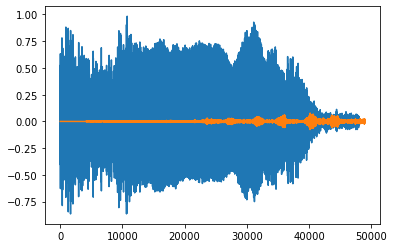

In [36]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

- blue: capuchin birds
- orange: another bird

## 3. Create Tensorflow Dataset

### 3.1 Define Paths to Positive and Negative Data

In [37]:
POS = os.path.join('source', 'Parsed_Capuchinbird_Clips')
NEG = os.path.join('source', 'Parsed_Not_Capuchinbird_Clips')

reach all wav files paths

### 3.2 Create Tensorflow Datasets

In [38]:
pos = tf.data.Dataset.list_files(POS+'\*.wav')
neg = tf.data.Dataset.list_files(NEG+'\*.wav')

catch wav files from paths

### 3.3 Add Labels and Combine Positive and Negative Samples

In [40]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

this method filling array like all positives are 1 and all negatives are 0

## 4. Determine Average Length of a Capuchin Call

### 4.1 Calculate Wave Cycle Length

In [46]:
lengths = []
for file in os.listdir(os.path.join('source', 'Parsed_Capuchinbird_Clips')):
    tensor_wave = load_wav_16k_mono(os.path.join('source', 'Parsed_Capuchinbird_Clips', file))
    lengths.append(len(tensor_wave))

slice through bigger clip for capturing the calls

### 4.2 Calculate Mean, Min and Max

In [48]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=54156>

In [49]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=32000>

In [50]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=80000>

- 54156 / 16000 = 3.38475 is average capuchinbird call time
- 32000 / 16000 = 2
- 80000 / 16000 = 5

## 5. Build Preprocessing Function to Convert to Spectrogram

### 5.1 Build Preprocessing Function

In [51]:
def preprocess(file_path, label):
    wav = load_wav_16k_mono(file_path)
    wav = wav[:48000]
    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav], 0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    
    return spectrogram, label

- load data into wav form
- take first 48000 steps of all signals
- if audio length large then fill above 48000 steps with 0
- overriding zeros on sample
- (create spectrogram) stft: short time fourier transform
- absolute everything
- expand_dims: encapsulate a spectrogram in set of arrays

### 5.2 Test Out the Function and Visualize Spectogram

In [59]:
# test out
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [60]:
spectrogram, label = preprocess(filepath, label)

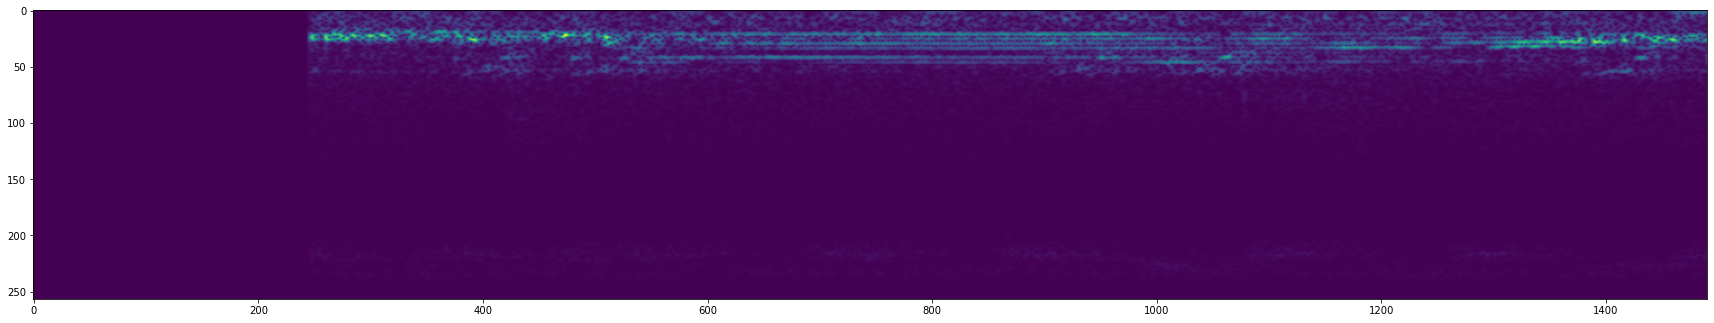

In [61]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

that spectrogram shows us is capbird call how looks in signals

In [62]:
filepath0, label0 = negatives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [63]:
spectrogram0, label0 = preprocess(filepath0, label0)

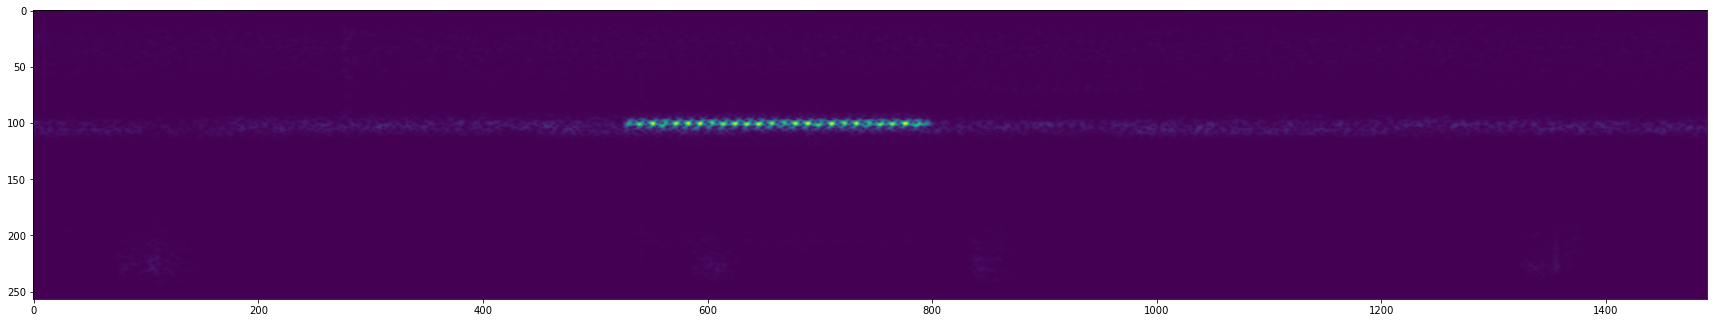

In [64]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram0)[0])
plt.show()

that spectrogram also shows us is not capbird call how looks in signals. how different!

## 6. Create Training and Testing Partitions

### 6.1 Create a Tensorflow Data Pipeline

In [65]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


- map: preprocess data on spectrogram method
- shuffle: mix neg and pos
- batch: train on 16 samples at a time
- prefetch: eliminate any cpu bottlenecking

### 6.2 Split into Training and Testing Partitions

In [67]:
len(data)*0.7

35.699999999999996

In [68]:
train = data.take(36)
test = data.skip(36).take(15)

- take 36 (%70) for training
- skip data that grabs for training
- take 15 (%30) for test

### 6.3 Test One Batch

In [69]:
samples, labels = train.as_numpy_iterator().next()

In [70]:
samples.shape

(16, 1491, 257, 1)

16 different example

## 7. Build Deep Learning Model